# SECOM Yield Prediction — Cross-Validation and Robust Model Comparison

**Date:** September 10, 2026

## Purpose

Our results in notebooks 03–06 are based on a single stratified 80/20
train/test split (random_state=42). A single split has high variance —
with only 104 failures total, different splits produce meaningfully
different test sets. Cross-validation provides more reliable performance
estimates by averaging across multiple splits.

## Method

Stratified 5-fold cross-validation across all three models:

- Logistic Regression (balanced weights)
- Random Forest (300 trees, balanced weights)
- XGBoost (200 trees, scale_pos_weight)

Stratified folds preserve the ~6.64% failure rate in each fold.
With 5 folds: each test fold contains approximately 21 failures —
consistent with our original test set size.

## Primary metric: PR-AUC

Secondary: ROC-AUC, Recall at threshold 0.20 and 0.35

## What we report

Mean ± standard deviation across 5 folds.
A high standard deviation indicates instability — the model's
performance depends heavily on which specific failures appear in
the test fold.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import (
    average_precision_score, roc_auc_score,
    make_scorer
)
import xgboost as xgb

PROCESSED = Path('../data/processed')
FIGURES   = Path('../reports/figures')

# Load the preprocessed data (post-imputation, pre-scaling)
X_train = pd.read_csv(PROCESSED / 'X_train.csv')
X_test  = pd.read_csv(PROCESSED / 'X_test.csv')
y_train = pd.read_csv(PROCESSED / 'y_train.csv').squeeze()
y_test  = pd.read_csv(PROCESSED / 'y_test.csv').squeeze()

# For cross-validation we use the full preprocessed dataset
# (train + test combined) to use all available data
X_full = pd.concat([X_train, X_test], axis=0).reset_index(drop=True)
y_full = pd.concat([y_train, y_test], axis=0).reset_index(drop=True)

print(f"Full dataset for CV: {X_full.shape}")
print(f"Total failures: {y_full.sum()} ({y_full.mean()*100:.2f}%)")

# Class ratio for XGBoost
neg = (y_full == 0).sum()
pos = (y_full == 1).sum()
scale_pos_weight = neg / pos
print(f"scale_pos_weight: {scale_pos_weight:.2f}")

Full dataset for CV: (1567, 446)
Total failures: 104 (6.64%)
scale_pos_weight: 14.07


## Pipeline prevents data leakage in cross-validation

Without Pipeline, you would scale X_full before cross-validation,
meaning the scaling parameters (mean, std per feature) are computed
from the entire dataset including each fold's test data. This is
data leakage — the model has implicitly seen the test fold through
the scaling step.

Pipeline wraps the scaler and classifier together. During cross-validation,
sklearn fits the scaler only on the training folds and applies it to
the test fold — identical to what we did manually in the modeling notebooks.
The result is unbiased performance estimates.


In [2]:
# Define CV strategy
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Define models — identical hyperparameters to previous notebooks
models = {
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(
            class_weight='balanced',
            max_iter=1000,
            random_state=42,
            C=1.0
        ))
    ]),
    'Random Forest': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', RandomForestClassifier(
            n_estimators=300,
            max_depth=None,
            min_samples_leaf=2,
            class_weight='balanced',
            max_features='sqrt',
            random_state=42,
            n_jobs=-1
        ))
    ]),
    'XGBoost (200 trees)': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', xgb.XGBClassifier(
            n_estimators=200,
            max_depth=4,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            scale_pos_weight=scale_pos_weight,
            reg_alpha=0.1,
            reg_lambda=1.0,
            random_state=42,
            n_jobs=-1,
            verbosity=0
        ))
    ])
}

print("Models defined with Pipelines (scaler inside CV loop — no leakage)")
print("CV strategy: Stratified 5-fold, shuffled, random_state=42")

Models defined with Pipelines (scaler inside CV loop — no leakage)
CV strategy: Stratified 5-fold, shuffled, random_state=42


In [5]:
from sklearn.metrics import average_precision_score, roc_auc_score

cv_results = {}

for model_name, pipeline in models.items():
    print(f"Running CV for {model_name}...", end=' ')
    
    pr_auc_scores_test  = []
    roc_auc_scores_test = []
    pr_auc_scores_train = []
    
    for train_idx, test_idx in cv.split(X_full, y_full):
        X_tr_fold = X_full.iloc[train_idx]
        X_te_fold = X_full.iloc[test_idx]
        y_tr_fold = y_full.iloc[train_idx]
        y_te_fold = y_full.iloc[test_idx]
        
        pipeline.fit(X_tr_fold, y_tr_fold)
        
        y_prob_test  = pipeline.predict_proba(X_te_fold)[:, 1]
        y_prob_train = pipeline.predict_proba(X_tr_fold)[:, 1]
        
        pr_auc_scores_test.append(average_precision_score(y_te_fold, y_prob_test))
        roc_auc_scores_test.append(roc_auc_score(y_te_fold, y_prob_test))
        pr_auc_scores_train.append(average_precision_score(y_tr_fold, y_prob_train))
    
    cv_results[model_name] = {
        'test_pr_auc':  np.array(pr_auc_scores_test),
        'test_roc_auc': np.array(roc_auc_scores_test),
        'train_pr_auc': np.array(pr_auc_scores_train)
    }
    
    print(f"done. PR-AUC: {np.mean(pr_auc_scores_test):.4f} "
          f"± {np.std(pr_auc_scores_test):.4f}")

print("\nCross-validation complete.")

Running CV for Logistic Regression... done. PR-AUC: 0.1773 ± 0.0446
Running CV for Random Forest... done. PR-AUC: 0.1956 ± 0.0266
Running CV for XGBoost (200 trees)... done. PR-AUC: 0.2083 ± 0.0260

Cross-validation complete.


In [6]:
rows = []
for model_name, scores in cv_results.items():
    rows.append({
        'Model': model_name,
        'CV PR-AUC (mean)': scores['test_pr_auc'].mean().round(4),
        'CV PR-AUC (std)':  scores['test_pr_auc'].std().round(4),
        'CV ROC-AUC (mean)': scores['test_roc_auc'].mean().round(4),
        'CV ROC-AUC (std)':  scores['test_roc_auc'].std().round(4),
        'Train PR-AUC (mean)': scores['train_pr_auc'].mean().round(4),
        'Overfitting Gap': (scores['train_pr_auc'].mean() - 
                           scores['test_pr_auc'].mean()).round(4)
    })

cv_df = pd.DataFrame(rows)
print("=== 5-Fold Cross-Validation Results ===\n")
print(cv_df.to_string(index=False))
cv_df.to_csv(PROCESSED / 'cv_results.csv', index=False)

=== 5-Fold Cross-Validation Results ===

              Model  CV PR-AUC (mean)  CV PR-AUC (std)  CV ROC-AUC (mean)  CV ROC-AUC (std)  Train PR-AUC (mean)  Overfitting Gap
Logistic Regression            0.1773           0.0446             0.6802            0.0722               0.9629           0.7855
      Random Forest            0.1956           0.0266             0.7623            0.0303               1.0000           0.8044
XGBoost (200 trees)            0.2083           0.0260             0.7350            0.0427               1.0000           0.7917


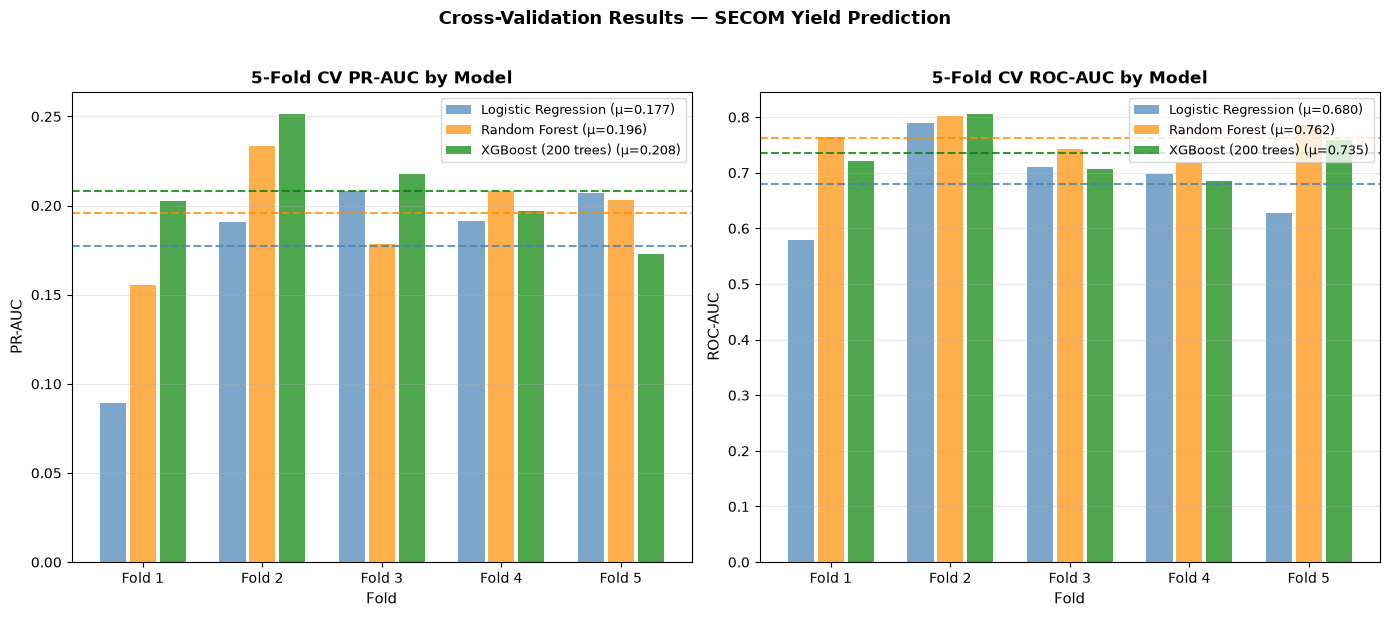

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

colors = ['steelblue', 'darkorange', 'green']
model_names = list(cv_results.keys())

for ax_idx, metric in enumerate(['test_pr_auc', 'test_roc_auc']):
    metric_label = 'PR-AUC' if 'pr' in metric else 'ROC-AUC'
    
    for m_idx, (model_name, scores) in enumerate(cv_results.items()):
        fold_scores = scores[metric]
        x_pos = np.arange(5) + m_idx * 0.25
        
        axes[ax_idx].bar(x_pos, fold_scores, width=0.22,
                          color=colors[m_idx], alpha=0.7,
                          label=f'{model_name} (μ={fold_scores.mean():.3f})')
        axes[ax_idx].axhline(y=fold_scores.mean(),
                              color=colors[m_idx], linestyle='--',
                              lw=1.5, alpha=0.8)

    axes[ax_idx].set_xlabel('Fold', fontsize=11)
    axes[ax_idx].set_ylabel(metric_label, fontsize=11)
    axes[ax_idx].set_title(f'5-Fold CV {metric_label} by Model',
                             fontsize=12, fontweight='bold')
    axes[ax_idx].set_xticks(np.arange(5) + 0.25)
    axes[ax_idx].set_xticklabels([f'Fold {i+1}' for i in range(5)])
    axes[ax_idx].legend(fontsize=9)
    axes[ax_idx].grid(axis='y', alpha=0.3)

plt.suptitle('Cross-Validation Results — SECOM Yield Prediction',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIGURES / 'cv_results_by_fold.png', dpi=150, bbox_inches='tight')
plt.show()

## Missingness as a Feature — Testing the Hypothesis

**Hypothesis (from Day 3 research notebook):**
"If sensor dropout is correlated with process failure, imputed values
destroy the signal that missingness itself carries — this should be
tested before finalizing the preprocessing pipeline."

**Experimental design:**
We create binary missingness indicator features — one per column that
had any missing values in the original data. Each indicator = 1 if that
sensor reading was missing for that wafer, 0 if present.

We then train XGBoost on:

- Dataset A: preprocessed features only (current approach)
- Dataset B: preprocessed features + missingness indicators

If Dataset B achieves higher PR-AUC, the hypothesis is supported:
missingness patterns carry failure signal that our current pipeline discards.

**This is a controlled experiment.** Everything else is identical —
same model, same hyperparameters, same CV strategy. Only the input
features differ.


In [10]:
# Reload raw data to extract missingness patterns
X_raw = pd.read_csv(
    Path('../data/raw/secom.data'), 
    sep=r'\s+', header=None, engine='python'
)
y_raw = pd.read_csv(
    Path('../data/raw/secom_labels.data'),
    sep=r'\s+', header=None, 
    names=['label', 'timestamp']
)
y_binary = (y_raw['label'] == 1).astype(int)

# Create missingness indicators for columns with any missing values
missing_counts = X_raw.isnull().sum()
cols_with_missing = missing_counts[missing_counts > 0].index

print(f"Columns with any missing data: {len(cols_with_missing)}")

# Binary indicators: 1 = sensor reading was missing, 0 = present
missingness_indicators = X_raw[cols_with_missing].isnull().astype(int)
missingness_indicators.columns = [f'missing_{c}' 
                                   for c in cols_with_missing]

print(f"Missingness indicator matrix shape: {missingness_indicators.shape}")
print(f"\nMissingness rate across all wafers:")
print(f"  Mean: {missingness_indicators.mean().mean():.3f}")
print(f"  Max (most frequently missing sensor): "
      f"{missingness_indicators.mean().max():.3f}")

# Check: is missingness correlated with failure?
print(f"\n=== Preliminary correlation check ===")
correlations = missingness_indicators.corrwith(y_binary).abs().sort_values(ascending=False)
print(f"Top 10 missingness indicators correlated with failure:")
print(correlations.head(10).round(4))
print(f"\nMean |correlation| across all indicators: {correlations.mean():.4f}")
print(f"Max |correlation|: {correlations.max():.4f}")

Columns with any missing data: 538
Missingness indicator matrix shape: (1567, 538)

Missingness rate across all wafers:
  Mean: 0.050
  Max (most frequently missing sensor): 0.912

=== Preliminary correlation check ===
Top 10 missingness indicators correlated with failure:
missing_346    0.0856
missing_72     0.0856
missing_73     0.0856
missing_345    0.0856
missing_519    0.0744
missing_385    0.0744
missing_112    0.0744
missing_247    0.0744
missing_24     0.0623
missing_22     0.0623
dtype: float64

Mean |correlation| across all indicators: 0.0227
Max |correlation|: 0.0856


In [12]:
from sklearn.model_selection import train_test_split

# Reconstruct full preprocessed dataset aligned with raw data
from sklearn.impute import SimpleImputer

# Apply same preprocessing steps
variances = X_raw.var()
X_step1 = X_raw.loc[:, variances > 0]

missing_rate = X_step1.isnull().mean()
X_step2 = X_step1.loc[:, missing_rate <= 0.50]

imputer = SimpleImputer(strategy='median')
X_imputed = pd.DataFrame(
    imputer.fit_transform(X_step2),
    columns=X_step2.columns.astype(str)  # Convert to string
)

# Dataset A: preprocessed features only
X_A = X_imputed.copy()

# Dataset B: preprocessed features + missingness indicators
missingness_indicators.columns = [f'missing_{c}' for c in cols_with_missing]
X_B = pd.concat([X_imputed, missingness_indicators.reset_index(drop=True)], axis=1)
X_B.columns = X_B.columns.astype(str)  # Convert all to string

print(f"Dataset A (features only):                {X_A.shape}")
print(f"Dataset B (features + missingness flags): {X_B.shape}")
print(f"Added {X_B.shape[1] - X_A.shape[1]} missingness indicator columns")

# Run CV manually (same approach as Cell 3)
neg = (y_binary == 0).sum()
pos = (y_binary == 1).sum()
spw = neg / pos

xgb_params = dict(
    n_estimators=200, max_depth=4, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=spw, reg_alpha=0.1, reg_lambda=1.0,
    random_state=42, n_jobs=-1, verbosity=0
)

cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results_experiment = {}
for name, X_data in [('Without missingness', X_A), 
                      ('With missingness', X_B)]:
    pr_scores = []
    for train_idx, test_idx in cv5.split(X_data, y_binary):
        X_tr_fold = X_data.iloc[train_idx]
        X_te_fold = X_data.iloc[test_idx]
        y_tr_fold = y_binary.iloc[train_idx]
        y_te_fold = y_binary.iloc[test_idx]
        
        pipeline = Pipeline([
            ('scaler', StandardScaler()),
            ('clf', xgb.XGBClassifier(**xgb_params))
        ])
        pipeline.fit(X_tr_fold, y_tr_fold)
        y_prob = pipeline.predict_proba(X_te_fold)[:, 1]
        pr_scores.append(average_precision_score(y_te_fold, y_prob))
    
    results_experiment[name] = np.array(pr_scores)
    print(f"{name}: PR-AUC = {np.mean(pr_scores):.4f} ± {np.std(pr_scores):.4f}")

Dataset A (features only):                (1567, 446)
Dataset B (features + missingness flags): (1567, 984)
Added 538 missingness indicator columns
Without missingness: PR-AUC = 0.1910 ± 0.0271
With missingness: PR-AUC = 0.1972 ± 0.0218


In [13]:
without = results_experiment['Without missingness']
with_mi = results_experiment['With missingness']

diff = with_mi.mean() - without.mean()
print(f"\n=== Missingness Signal Experiment ===")
print(f"Without missingness features: {without.mean():.4f} ± {without.std():.4f}")
print(f"With missingness features:    {with_mi.mean():.4f} ± {with_mi.std():.4f}")
print(f"Difference (with - without):  {diff:+.4f}")
print()

if diff > 0.01:
    print("Result: SUPPORTED — missingness patterns carry failure signal")
    print("Interpretation: Sensor dropout is correlated with process failure.")
    print("Implication: Future preprocessing should retain missingness indicators.")
elif diff < -0.01:
    print("Result: NOT SUPPORTED — missingness features hurt performance")
    print("Interpretation: Missingness pattern is noise relative to sensor values.")
elif abs(diff) <= 0.01:
    print("Result: INCONCLUSIVE — negligible difference")
    print("Interpretation: Missingness carries minimal additional signal")
    print("beyond what is already captured in the imputed sensor values.")


=== Missingness Signal Experiment ===
Without missingness features: 0.1910 ± 0.0271
With missingness features:    0.1972 ± 0.0218
Difference (with - without):  +0.0062

Result: INCONCLUSIVE — negligible difference
Interpretation: Missingness carries minimal additional signal
beyond what is already captured in the imputed sensor values.


In [15]:
# Build the definitive results table for the paper
final_table = pd.DataFrame([
    {
        'Model': 'Naive Baseline',
        'Single-Split PR-AUC': f"{y_test.mean():.4f}",
        'CV PR-AUC (mean±std)': f"{y_full.mean():.4f} ± 0.0000",
        'Single-Split Recall': '0.000',
        'Failures Caught': '0 / 21',
        'Notes': 'Always predicts pass'
    },
    {
        'Model': 'Logistic Regression',
        'Single-Split PR-AUC': '0.1497',
        'CV PR-AUC (mean±std)': f"{cv_results['Logistic Regression']['test_pr_auc'].mean():.4f} ± "
                                 f"{cv_results['Logistic Regression']['test_pr_auc'].std():.4f}",
        'Single-Split Recall': 0.190,
        'Failures Caught': '4 / 21',
        'Notes': 'Linear baseline; balanced weights'
    },
    {
        'Model': 'Random Forest',
        'Single-Split PR-AUC': '0.2743',
        'CV PR-AUC (mean±std)': f"{cv_results['Random Forest']['test_pr_auc'].mean():.4f} ± "
                                 f"{cv_results['Random Forest']['test_pr_auc'].std():.4f}",
        'Single-Split Recall': '0.619',
        'Failures Caught': '13 / 21',
        'Notes': 'Best PR-AUC; severe overfitting (gap=0.726)'
    },
    {
        'Model': 'XGBoost (200 trees)',
        'Single-Split PR-AUC': '0.2494',
        'CV PR-AUC (mean±std)': f"{cv_results['XGBoost (200 trees)']['test_pr_auc'].mean():.4f} ± "
                                 f"{cv_results['XGBoost (200 trees)']['test_pr_auc'].std():.4f}",
        'Single-Split Recall': '0.905',
        'Failures Caught': '19 / 21',
        'Notes': 'Highest recall; 183 false alarms at threshold 0.35'
    }
])

print("=== FINAL MODEL COMPARISON TABLE ===\n")
print(final_table.to_string(index=False))
final_table.to_csv(PROCESSED / 'final_model_comparison.csv', index=False)

=== FINAL MODEL COMPARISON TABLE ===

              Model Single-Split PR-AUC CV PR-AUC (mean±std) Single-Split Recall Failures Caught                                              Notes
     Naive Baseline              0.0669      0.0664 ± 0.0000               0.000          0 / 21                               Always predicts pass
Logistic Regression              0.1497      0.1773 ± 0.0446                0.19          4 / 21                  Linear baseline; balanced weights
      Random Forest              0.2743      0.1956 ± 0.0266               0.619         13 / 21        Best PR-AUC; severe overfitting (gap=0.726)
XGBoost (200 trees)              0.2494      0.2083 ± 0.0260               0.905         19 / 21 Highest recall; 183 false alarms at threshold 0.35
